# 1. Data Exploration

Import necessary packages

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## 1.1 Data Loading

Load Bitcoin dataset and inspect its structure.

In [135]:
df = pd.read_csv("../data/raw/bitcoin_data_unsupervised_ml.csv")
df.head()

,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
0,2009-01-03,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
1,2009-01-04,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
2,2009-01-05,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
3,2009-01-06,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
4,2009-01-07,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN


Early Bitcoin data is generally full of NAs - check latest

In [136]:
pd.set_option('display.max_columns', None) # too many columns to display, so set option to display all columns

df.tail(5)

,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
6264,2026-02-27,704075.0,56293301.0,1.772248e+09,1.772248e+09,141.0,1.207325,1.316988e+12,1.316971e+12,3.017286,19773.847238,1.302387e+09,18754.877779,1.235274e+09,1.012110e+09,440.625,2.902138e+07,1.0,65864.135817,-22.169797,-26.142892,67519.264529,33.285934,57238.910529,67519.264529,1.999553e+07,2.666943e+06,1.756559e+11,2.083144e+07,411023.0,921091.0,1.240468e+10
6265,2026-02-28,640533.0,56304427.0,1.772331e+09,1.772331e+09,143.0,1.227561,1.339043e+12,1.339026e+12,2.521095,10493.111565,7.026779e+08,11713.430058,7.843973e+08,1.026466e+09,446.875,2.992527e+07,1.0,66965.635309,-20.509696,-20.769853,65864.135817,34.131692,55802.619507,65864.135817,1.999598e+07,2.666308e+06,1.785510e+11,2.083155e+07,426230.0,898825.0,1.291259e+10
6266,2026-03-01,602506.0,56312775.0,1.772420e+09,1.772420e+09,149.0,1.205248,1.314437e+12,1.314419e+12,2.577225,10511.379642,6.909500e+08,11268.921974,7.407459e+08,1.069534e+09,465.625,3.060717e+07,1.0,65733.521260,-23.427101,-21.761674,66965.635309,34.105436,56767.313419,66965.635309,1.999644e+07,2.666004e+06,1.752458e+11,2.083167e+07,464241.0,974438.0,1.209887e+10
6267,2026-03-02,690831.0,56319965.0,1.772510e+09,1.772510e+09,136.0,1.263761,1.378237e+12,1.378220e+12,2.671951,22536.780379,1.553294e+09,27854.922733,1.919834e+09,9.762193e+08,425.000,2.929212e+07,1.0,68922.624297,-26.933024,-12.426258,65733.521260,33.910062,55887.981786,65733.521260,1.999687e+07,2.660950e+06,1.833997e+11,2.083177e+07,420983.0,899611.0,1.657544e+10
6268,2026-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68922.624297,33.898789,58930.026600,68922.624297,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.2 Data Structure

There are 32 columns per observation (daily observations) and 6269 observations.

In [137]:
df.shape

(6269, 32)

In [138]:
df.columns.tolist()

['time',
 'AdrActCnt',
 'AdrBalCnt',
 'AssetCompletionTime',
 'AssetEODCompletionTime',
 'BlkCnt',
 'CapMVRVCur',
 'CapMrktCurUSD',
 'CapMrktEstUSD',
 'FeeTotNtv',
 'FlowInExNtv',
 'FlowInExUSD',
 'FlowOutExNtv',
 'FlowOutExUSD',
 'HashRate',
 'IssTotNtv',
 'IssTotUSD',
 'PriceBTC',
 'PriceUSD',
 'ROI1yr',
 'ROI30d',
 'ReferenceRate',
 'ReferenceRateETH',
 'ReferenceRateEUR',
 'ReferenceRateUSD',
 'SplyCur',
 'SplyExNtv',
 'SplyExUSD',
 'SplyExpFut10yr',
 'TxCnt',
 'TxTfrCnt',
 'volume_reported_spot_usd_1d']

## 1.3 First Cleaning: Domain Knowledge and Economic Reasoning

Before exploring the whole data set, a first clean up of redundant columns and possible renaming of columns makes sense. I will exclude any variables that do not make economically sense for the specific case of Regime-Detection in Bitcoin data, that is bull- and bearmarket structures and the turning points in between, based on domain knowledge and economic reasoning.

The case of Bitcoin exhibits 2 specific structures in its data:

1) There was a huge growth trend over the years that again should be represented in most variables. The growth trend as such is not a problem since I can handle this by constructing later in the feature engineering stage Moving Averages and %-Change Variables that capture the structure of different regimes instead of the long term trend, while also minimizing the noise of high volatility. For now, variables that do have trends but do make economically sense for detecting regimes when transformed accordingly will be kept.
2) Bitcoin does have monotonous, deterministic trends in specific variables, i.e. Supply. The supply production follows a deterministic function that grows asymptotically towards a limit - monotonously but growing less the further in the future. Even if transformed by %-changes, it would still only contain information about 'where in the time horizon are we' and with that, only help the algorithms to cluster between 'early time' vs 'late time' accordingly, since such variables would make early appear more similar to early and late more similar to late automatically. Such variables will be excluded directly in this stage.

The general difficulty with using Unsupervised ML with Bitcoin here is generally that variables might contain the information about 'where we are in time', and if such, would lead the algorithms to cluster around time. That is exactly NOT what I want, as I want to find points in time that automatically look more similar based on their time independent features - in order to find possible signals that can indicate regime changes in Bitcoin at any time, I need to find features that are time independent and can happen at any time. Transformation with Moving Averages and %-Changes can give me such features, but not for every case as discussed with monotonous functions. 

I do think that this step here, together with the feature engineering, might be the most important of the whole project, and if the algorithms do not find anything, might also be the place I revisit again to iterate.

In the next step, I will explore my variables and do a first selection.

### Columns per Observation: Meaning and First Selection

I explore here the variables with its meaning, its category and the decision of keeping (KEEP), deleting (DELETE) or keeping with caution (Keep - CARE) dependend on domain knowledge and economic reasoning. Generally, the data is based on daily observations and as such represent, if not indicated else, the daily respective data - i.e. total number of transactions = total n(transcations) in that day.

| Variable | Meaning | Category | First Decision | Reason |
|-----------|-----------|-----------|-----------|-----------|
| time | Observation date | Time | Keep | Time variable |
| AssetCompletionTime | CoinMetrics processing timestamp | Metadata | DELETE | Only CoinMetrics metadata |
| AssetEODCompletionTime | End-of-day completion timestamp | Metadata | DELETE | Only CoinMetrics metadata |
| AdrActCnt | Number of active addresses | Network Activity | Keep - CARE | Useful demand metric if it fluctuates; need to check after transformation |
| AdrBalCnt | Number of addresses with balance | Network Activity | Keep - CARE | Useful demand metric, but might grow constantly; need to check after transformation |
| BlkCnt | Number of blocks mined | Network Activity | Keep - CARE | Should be constant, as Bitcoin adjusts difficulty of the network to match 1 block all 10 minutes every 14 days; Still, check for structure, as the gap of 14 days might have important information for regimes |
| TxCnt | Total number of transactions | Network Activity | Keep | Useful demand metric |
| TxTfrCnt | Number of transfer transactions | Network Activity | Keep | Useful demand metric |
| HashRate | Estimated Bitcoin hash rate | Mining | Keep | Useful mining metric |
| FeeTotNtv | Total fees paid in BTC | Mining / Usage | Keep - CARE | Useful demand metric, but should be in terms of USD; Check with data exploration and maybe transform with daily price of BTC to amount of USD  |
| IssTotNtv | Newly issued BTC | Supply | DELETE | Proxy for halving cycles; constant function of asymptotic growth all 4 years, only a time indicator |
| IssTotUSD | USD value of newly issued BTC | Supply | Keep - CARE | Potentially useful; as should not just grow constantly; need to check |
| SplyCur | Current circulating supply | Supply | DELETE | Deterministic asymptotic function, only indicator of time |
| SplyExNtv | BTC held on exchanges | Exchange Activity | Keep | Perfect to assess how Holdings changed in 30/90/180 day changes; Ideal with %-change to assess for the longterm trend |
| SplyExUSD | USD value held on exchanges | Exchange Activity | DELETE | USD of upper version; the fluctuations in Price would lead to random noise in the holdings, as the BTC that stay on the exchange would fluctuate in its price - therefore not a good variable for structure |
| SplyExpFut10yr | Expected supply in 10 years | Supply | DELETE | Economically not informative, dependent on deterministic function and again only a time indicator |
| FlowInExNtv | BTC inflow to exchanges | Exchange Activity | DELETE | People think in terms of usd value, when putting BTC onto exchanges to sell, and not in terms of how many BTC do I want to sell |
| FlowInExUSD | USD inflow to exchanges | Exchange Activity | Keep | People think in terms of usd value, when putting BTC onto exchanges to sell, and not in terms of how many BTC do I want to sell |
| FlowOutExNtv | BTC outflow from exchanges | Exchange Activity | DELETE | People take out value, not BTC |
| FlowOutExUSD | USD outflow from exchanges | Exchange Activity | Keep | People take out value, not BTC |
| PriceUSD | Bitcoin price in USD | Market | Keep | Core market variable |
| PriceBTC | Bitcoin price in BTC | Market | DELETE | Constant / useless |
| ReferenceRate | CoinMetrics reference price | Market | DELETE | Redundant with PriceUSD |
| ReferenceRateUSD | CoinMetrics reference price USD | Market | DELETE | Redundant with PriceUSD |
| ReferenceRateEUR | CoinMetrics reference price EUR | Market | DELETE | Redundant with PriceUSD |
| ReferenceRateETH | BTC/ETH exchange rate | Market | Keep | Proxy for BTC vs crypto market, general adoption and market sentiment |
| CapMrktCurUSD | Current market capitalization | Market | DELETE | = Price x Current Supply; and since Supply is a monotonous asymptotic function, only adds a time feature to the price -> worse than price |
| CapMrktEstUSD | Estimated market capitalization | Market | DELETE | Redundant |
| CapMVRVCur | MVRV ratio | Valuation | Keep | Useful valuation metric |
| ROI30d | 30-day return | Returns | DELETE | I will construct my own %-change features later, keeping it here strictly separated |
| ROI1yr | 1-year return | Returns | DELETE | I will construct my own %-change features later, keeping it here strictly separated |
| volume_reported_spot_usd_1d | Spot trading volume (USD) | Trading Activity | Keep | Useful demand metric |

16 Columns will be deleted completely as they do not contain useful information based on domain knowledge, leaving the dataset with 32 columns. For the specific reasons, see the table above.

5 other columns are labelled as Keep - CARE due to possible redundancy depending on how the data is measured and looks like; These could be potentially omitted after the exploration and engineering phase.

To do a first clean up, I will delete the 16 columns from the dataset and rename the remaining variables in a comprehensible way.

### Columns per Observation: Renamed and First Cleaning


The following Columns are kept for now and renamed according to the 'New Name'

32 Columns - 16 columns = 16 columns; 11 'Keep' and 5 'Keep - CARE'

| New Name             | Old Name                    | Meaning                          | Category          | First Decision | Reason                                                                                         |
| -------------------- | --------------------------- | -------------------------------- | ----------------- | -------------- | ---------------------------------------------------------------------------------------------- |
| date                 | time                        | Observation date                 | Time              | Keep           | Time variable                                                                                  |
| active_addresses     | AdrActCnt                   | Number of active addresses       | Network Activity  | Keep - CARE    | Useful demand metric if it fluctuates; need to check after transformation                      |
| nonzero_addresses    | AdrBalCnt                   | Number of addresses with balance | Network Activity  | Keep - CARE    | Useful demand metric, but might grow constantly; need to check after transformation            |
| block_count          | BlkCnt                      | Number of blocks mined           | Network Activity  | Keep - CARE    | Should be almost constant; check whether difficulty-adjustment cycles contain useful structure |
| transaction_count    | TxCnt                       | Total number of transactions     | Network Activity  | Keep           | Useful demand metric                                                                           |
| transfer_count       | TxTfrCnt                    | Number of transfer transactions  | Network Activity  | Keep           | Useful demand metric                                                                           |
| hash_rate            | HashRate                    | Estimated Bitcoin hash rate      | Mining            | Keep           | Useful mining metric                                                                           |
| total_fees_btc       | FeeTotNtv                   | Total fees paid in BTC           | Mining / Usage    | Keep - CARE    | Useful demand metric, but should be in terms of USD; Check with data exploration and maybe transform with daily price of BTC to amount of USD    |
| issuance_usd         | IssTotUSD                   | USD value of newly issued BTC    | Supply            | Keep - CARE    | Potentially useful; unlike BTC issuance not purely deterministic                               |
| exchange_supply_btc  | SplyExNtv                   | BTC held on exchanges            | Exchange Activity | Keep           | Ideal to analyse long-term accumulation/distribution behaviour                                 |
| exchange_inflow_usd  | FlowInExUSD                 | USD inflow to exchanges          | Exchange Activity | Keep           | Potentially useful sentiment and selling-pressure signal                                       |
| exchange_outflow_usd | FlowOutExUSD                | USD outflow from exchanges       | Exchange Activity | Keep           | Potentially useful accumulation signal                                                         |
| price_usd            | PriceUSD                    | Bitcoin price in USD             | Market            | Keep           | Core market variable                                                                           |
| btc_eth_ratio        | ReferenceRateETH            | BTC/ETH exchange rate            | Market            | Keep           | Proxy for BTC relative strength versus the broader crypto market                               |
| mvrv_ratio           | CapMVRVCur                  | MVRV ratio                       | Valuation         | Keep           | Useful valuation metric                                                                        |
| spot_volume_usd      | volume_reported_spot_usd_1d | Spot trading volume (USD)        | Trading Activity  | Keep           | Useful demand/liquidity metric                                                                 |


In [139]:
# ============================================================
# Remove clearly irrelevant columns based on domain knowledge
# ============================================================

columns_to_drop = [
    "AssetCompletionTime",
    "AssetEODCompletionTime",
    "IssTotNtv",
    "SplyCur",
    "SplyExUSD",
    "SplyExpFut10yr",
    "FlowInExNtv",
    "FlowOutExNtv",
    "PriceBTC",
    "ReferenceRate",
    "ReferenceRateUSD",
    "ReferenceRateEUR",
    "CapMrktCurUSD",
    "CapMrktEstUSD",
    "ROI30d",
    "ROI1yr"
]

df = df.drop(columns=columns_to_drop)

print(f"Remaining columns: {len(df.columns)}")
print(df.columns.tolist())

Remaining columns: 16
['time', 'AdrActCnt', 'AdrBalCnt', 'BlkCnt', 'CapMVRVCur', 'FeeTotNtv', 'FlowInExUSD', 'FlowOutExUSD', 'HashRate', 'IssTotUSD', 'PriceUSD', 'ReferenceRateETH', 'SplyExNtv', 'TxCnt', 'TxTfrCnt', 'volume_reported_spot_usd_1d']


In [140]:
# ============================================================
# Rename variables for readability
# ============================================================

rename_dict = {
    "time": "date",
    "AdrActCnt": "active_addresses",
    "AdrBalCnt": "nonzero_addresses",
    "BlkCnt": "block_count",
    "TxCnt": "transaction_count",
    "TxTfrCnt": "transfer_count",
    "HashRate": "hash_rate",
    "FeeTotNtv": "total_fees_btc",
    "IssTotUSD": "issuance_usd",
    "SplyExNtv": "exchange_supply_btc",
    "FlowInExUSD": "exchange_inflow_usd",
    "FlowOutExUSD": "exchange_outflow_usd",
    "PriceUSD": "price_usd",
    "ReferenceRateETH": "btc_eth_ratio",
    "CapMVRVCur": "mvrv_ratio",
    "volume_reported_spot_usd_1d": "spot_volume_usd"
}

df = df.rename(columns=rename_dict)

print(df.columns.tolist())

['date', 'active_addresses', 'nonzero_addresses', 'block_count', 'mvrv_ratio', 'total_fees_btc', 'exchange_inflow_usd', 'exchange_outflow_usd', 'hash_rate', 'issuance_usd', 'price_usd', 'btc_eth_ratio', 'exchange_supply_btc', 'transaction_count', 'transfer_count', 'spot_volume_usd']


In [141]:
# ============================================================
# Convert date column
# ============================================================

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.head()

,date,active_addresses,nonzero_addresses,block_count,mvrv_ratio,total_fees_btc,exchange_inflow_usd,exchange_outflow_usd,hash_rate,issuance_usd,price_usd,btc_eth_ratio,exchange_supply_btc,transaction_count,transfer_count,spot_volume_usd
0,2009-01-03,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN
1,2009-01-04,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN
2,2009-01-05,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN
3,2009-01-06,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN
4,2009-01-07,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN


In [142]:
# ============================================================
# Save first cleaned dataset
# ============================================================

df.to_csv(
    "../data/processed/bitcoin_initial_clean.csv",
    index=False
)

## 1.4 Missing Values

I use the initial cleaned dataset from now on for the data exploration. As seen in 1.1, the latest observation was not complete (likely due to coinmetrics only having all the information of a day when the day was completed, and as such 'today' would be incomplete) and will be cut out of the dataset before I continue with exploration.

In [143]:
# Remove latest date because data collection was not yet be complete
latest_date = df["date"].max()

df = df[df["date"] < latest_date].copy()

print(f"Removed latest date: {latest_date}")
print(f"Remaining observations: {len(df)}")

Removed latest date: 2026-03-03 00:00:00
Remaining observations: 6268


Next I check on completeness of the dataset, considering NAs and Null values.

In [144]:
# number of observations and features

df.shape

(6268, 16)

In [145]:
# check for missing values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6268 entries, 0 to 6267
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  6268 non-null   datetime64[us]
 1   active_addresses      6268 non-null   float64       
 2   nonzero_addresses     6268 non-null   float64       
 3   block_count           6268 non-null   float64       
 4   mvrv_ratio            5707 non-null   float64       
 5   total_fees_btc        6268 non-null   float64       
 6   exchange_inflow_usd   5707 non-null   float64       
 7   exchange_outflow_usd  5707 non-null   float64       
 8   hash_rate             6262 non-null   float64       
 9   issuance_usd          5707 non-null   float64       
 10  price_usd             5707 non-null   float64       
 11  btc_eth_ratio         6 non-null      float64       
 12  exchange_supply_btc   6268 non-null   float64       
 13  transaction_count     6268 no

Lets make it a bit more comprehensive.

In [146]:
# Show number of missing values per column, sorted in descending order

df.isna().sum().sort_values(ascending=False)

btc_eth_ratio           6262
exchange_inflow_usd      561
mvrv_ratio               561
exchange_outflow_usd     561
spot_volume_usd          561
price_usd                561
issuance_usd             561
hash_rate                  6
total_fees_btc             0
active_addresses           0
nonzero_addresses          0
block_count                0
date                       0
exchange_supply_btc        0
transaction_count          0
transfer_count             0
dtype: int64

2 Intersting things:

1) btc eth ratio is basically NA only - does not make sense as ETH has been here since 11 years - will check this; if the data is really missing, will be deleted
2) price, market cap variables are missing for 561 observations (and 591 / 926 for 30d / 1d returns, what makes completely sense as they are not possible to calculate with prior NA) -> Should be the early Bitcoin years, where there was no price tracking. Will check if that holds true and if so, delete the early period of time for BTC.

The 6 NA in hash rates will be checked afterwards

### Check BTC ETH Ratio

In [147]:
# Show rows where btc_eth_ratio is not missing

df[df["btc_eth_ratio"].notna()][["date", "btc_eth_ratio"]]

,date,btc_eth_ratio
6262,2026-02-25,34.560225
6263,2026-02-26,33.071973
6264,2026-02-27,33.285934
6265,2026-02-28,34.131692
6266,2026-03-01,34.105436
6267,2026-03-02,33.910062


Only the latest 6 obversations have data here.

In [148]:
df.tail(10)

,date,active_addresses,nonzero_addresses,block_count,mvrv_ratio,total_fees_btc,exchange_inflow_usd,exchange_outflow_usd,hash_rate,issuance_usd,price_usd,btc_eth_ratio,exchange_supply_btc,transaction_count,transfer_count,spot_volume_usd
6258,2026-02-21,579813.0,56243978.0,119.0,1.242773,2.046908,5.506448e+08,6.692046e+08,8.541919e+08,2.529519e+07,68020.667761,NaN,2.673947e+06,344028.0,730062.0,5.002388e+09
6259,2026-02-22,525709.0,56258562.0,164.0,1.234286,1.864387,6.113151e+08,6.527799e+08,1.177206e+09,3.461939e+07,67550.024077,NaN,2.673727e+06,538994.0,957682.0,4.752978e+09
6260,2026-02-23,684644.0,56216762.0,148.0,1.183184,2.622654,1.393277e+09,1.367970e+09,1.062356e+09,2.991908e+07,64689.912331,NaN,2.674295e+06,448909.0,880366.0,1.531381e+10
6261,2026-02-24,661423.0,56254237.0,165.0,1.174332,2.813820,1.744825e+09,1.719438e+09,1.184384e+09,3.306381e+07,64123.751078,NaN,2.675238e+06,568326.0,1080612.0,1.379567e+10
6262,2026-02-25,650235.0,56260172.0,156.0,1.246123,2.789485,1.293807e+09,1.668991e+09,1.119781e+09,3.316878e+07,68038.522179,34.560225,2.670075e+06,481942.0,988995.0,1.882147e+10
6263,2026-02-26,693519.0,56267714.0,140.0,1.236811,3.461600,1.611461e+09,1.946496e+09,1.004932e+09,2.953968e+07,67519.264529,33.071973,2.665512e+06,429268.0,940687.0,1.401673e+10
6264,2026-02-27,704075.0,56293301.0,141.0,1.207325,3.017286,1.302387e+09,1.235274e+09,1.012110e+09,2.902138e+07,65864.135817,33.285934,2.666943e+06,411023.0,921091.0,1.240468e+10
6265,2026-02-28,640533.0,56304427.0,143.0,1.227561,2.521095,7.026779e+08,7.843973e+08,1.026466e+09,2.992527e+07,66965.635309,34.131692,2.666308e+06,426230.0,898825.0,1.291259e+10
6266,2026-03-01,602506.0,56312775.0,149.0,1.205248,2.577225,6.909500e+08,7.407459e+08,1.069534e+09,3.060717e+07,65733.521260,34.105436,2.666004e+06,464241.0,974438.0,1.209887e+10
6267,2026-03-02,690831.0,56319965.0,136.0,1.263761,2.671951,1.553294e+09,1.919834e+09,9.762193e+08,2.929212e+07,68922.624297,33.910062,2.660950e+06,420983.0,899611.0,1.657544e+10


BTC ETH ratio is indeed missing for nearly the whole dataset - will be deleted as such. Possibly in later stages, I could add manually the ETH or even better the whole crypto market capitalization excluding Bitcoin and calculate the BTC market cap vs rest of crypto market cap ratio to have an additional market sentiment variable that captures how Bitcoin performs against the general market (economically would make much sense as Bitcoin dominates during certain market regimes vs loses market share in others).

In [149]:
# Remove BTC/ETH ratio due to insufficient data coverage

df = df.drop(columns=["btc_eth_ratio"])

print(df.shape)

(6268, 15)


#### Removal of BTC/ETH Ratio

The BTC/ETH exchange rate (`ReferenceRateETH`) was initially retained because it could potentially capture Bitcoin's relative strength against the broader crypto market.

However, data exploration revealed that only 6 non-missing observations were available out of 6,268 daily observations (>99.9% missing values). The variable was therefore excluded from further analysis due to insufficient coverage.

### 561 NAs Variable Set

Next I check for the various variables that miss 561 Observations

In [150]:
df[df["price_usd"].isna()].head()

,date,active_addresses,nonzero_addresses,block_count,mvrv_ratio,total_fees_btc,exchange_inflow_usd,exchange_outflow_usd,hash_rate,issuance_usd,price_usd,exchange_supply_btc,transaction_count,transfer_count,spot_volume_usd
0,2009-01-03,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN
1,2009-01-04,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN
2,2009-01-05,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN
3,2009-01-06,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN
4,2009-01-07,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN


Lets see when we first have values that are not NA - probably at observation 561 if my hypothesis holds true.

In [151]:
df[df["price_usd"].notna()].head()

,date,active_addresses,nonzero_addresses,block_count,mvrv_ratio,total_fees_btc,exchange_inflow_usd,exchange_outflow_usd,hash_rate,issuance_usd,price_usd,exchange_supply_btc,transaction_count,transfer_count,spot_volume_usd
561,2010-07-18,860.0,52190.0,172.0,146.038332,0.79,0.0,0.0,0.001552,738.224000,0.085840,0.0,248.0,396.0,5.091994
562,2010-07-19,929.0,52311.0,174.0,62.565130,0.05,0.0,0.0,0.001570,702.960000,0.080800,0.0,334.0,512.0,49.661300
563,2010-07-20,936.0,52456.0,181.0,45.106630,0.00,0.0,0.0,0.001633,676.358346,0.074736,0.0,423.0,738.0,20.589520
564,2010-07-21,784.0,52521.0,207.0,38.357560,0.00,0.0,0.0,0.001868,819.646128,0.079193,0.0,247.0,377.0,42.262200
565,2010-07-22,594.0,52715.0,176.0,25.132348,0.00,0.0,0.0,0.001588,514.533891,0.058470,0.0,221.0,344.0,129.784280


The '561' variables start having no NAs exactly at observation no 561, what means that all observations before (starting with 0) have NAs - I will delete all prior observations and check again for NAs.

In [152]:
# ============================================================
# Remove early observations before full market data coverage
# ============================================================

print("Observations before filtering:", len(df))

df = df[df["price_usd"].notna()].copy()

print("Observations after filtering:", len(df))
print("First remaining date:", df["date"].min())

Observations before filtering: 6268
Observations after filtering: 5707
First remaining date: 2010-07-18 00:00:00


In [153]:
# Quick check for missing values again after filtering

df.isna().sum().sort_values(ascending=False)

date                    0
active_addresses        0
nonzero_addresses       0
block_count             0
mvrv_ratio              0
total_fees_btc          0
exchange_inflow_usd     0
exchange_outflow_usd    0
hash_rate               0
issuance_usd            0
price_usd               0
exchange_supply_btc     0
transaction_count       0
transfer_count          0
spot_volume_usd         0
dtype: int64

Perfect! Everything as it should be, and even the missing hashrates problem got solved! I next check for values of 0; in early Bitcoin times there might have generally maybe not been data around and just filled up as a 0 instead of an NA for some reasons - so I do a precautious check

In [154]:
(df == 0).sum().sort_values(ascending=False)

exchange_outflow_usd    298
exchange_inflow_usd     293
exchange_supply_btc     280
total_fees_btc           80
spot_volume_usd           6
nonzero_addresses         0
date                      0
block_count               0
mvrv_ratio                0
active_addresses          0
hash_rate                 0
price_usd                 0
issuance_usd              0
transaction_count         0
transfer_count            0
dtype: int64

Generally, the 0 appear with mostly exchange data. Its not very realistic that the supply on exchanges would have been exactly zero after having the first inflow, so we'll check for the first not-0 observation in exchange supply. Additionally

In [155]:
df[df["exchange_supply_btc"] > 0].head()

,date,active_addresses,nonzero_addresses,block_count,mvrv_ratio,total_fees_btc,exchange_inflow_usd,exchange_outflow_usd,hash_rate,issuance_usd,price_usd,exchange_supply_btc,transaction_count,transfer_count,spot_volume_usd
841,2011-04-24,4821.0,96648.0,162.0,4.275436,4.722223,228.477791,0.0,0.743681,13219.072180,1.631984,140.0,2291.0,4655.0,36076.006302
842,2011-04-25,5053.0,97115.0,192.0,4.061132,8.931643,0.000000,0.0,0.881400,15019.042899,1.564484,140.0,2342.0,5163.0,21226.889728
843,2011-04-26,6053.0,97408.0,195.0,4.514597,4.990500,0.000000,0.0,0.895172,17265.698679,1.770841,140.0,3203.0,6771.0,40211.166904
844,2011-04-27,7488.0,97696.0,183.0,4.767442,9.171679,0.000000,0.0,0.840084,17414.060020,1.903176,140.0,4394.0,8927.0,62403.354408
845,2011-04-28,6130.0,98142.0,164.0,5.535625,6.610500,0.000000,0.0,0.752862,18743.104620,2.285744,140.0,2819.0,5761.0,203392.458484


841 - 561 = 280 observations, so we can conclude that all prior observations have 0 in exchange supply, and are therefore basically are NAs. Outflows and Inflows can be 0 in early years as there might have been days where it simply happened that noone wanted to take out / put in their Bitcoins.

In [156]:
# ============================================================
# Remove early observations before '0' values for exchange supply'
# ============================================================

print("Observations before filtering:", len(df))

df = df[df["exchange_supply_btc"] > 0].copy()

print("Observations after filtering:", len(df))
print("First remaining date:", df["date"].min())

Observations before filtering: 5707
Observations after filtering: 5427
First remaining date: 2011-04-24 00:00:00


In [157]:
# Quick check afterwards

(df == 0).sum().sort_values(ascending=False)

exchange_outflow_usd    18
exchange_inflow_usd     13
spot_volume_usd          6
nonzero_addresses        0
block_count              0
active_addresses         0
date                     0
total_fees_btc           0
mvrv_ratio               0
issuance_usd             0
hash_rate                0
price_usd                0
exchange_supply_btc      0
transaction_count        0
transfer_count           0
dtype: int64

Outflow and Inflow both lost 280, the rest of existing '0' are reasonable and with that the Missing Values filtering is finished. I continue with the real analysis

## 1.5 Exploratory Data Analysis

I will first do a general overview of the core descriptive stats and histograms.

### Descriptive Statistics

In [158]:
# Get a first numeric overview of the dataset

df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,5427,2018-09-27 00:00:00,2011-04-24 00:00:00,2015-01-09 12:00:00,2018-09-27 00:00:00,2022-06-14 12:00:00,2026-03-02 00:00:00,NaN
active_addresses,5427.0,579747.679749,4821.0,232339.0,662757.0,853805.5,1366494.0,346790.602648
nonzero_addresses,5427.0,24339352.162521,96648.0,4001521.0,22732417.0,42204022.5,56319965.0,19266373.428396
block_count,5427.0,150.953381,58.0,139.0,150.0,161.0,307.0,19.512787
mvrv_ratio,5427.0,1.794291,0.386829,1.278479,1.705717,2.164732,7.743139,0.783742
total_fees_btc,5427.0,55.243488,1.864387,12.744622,24.032995,53.310762,1495.748916,95.609497
exchange_inflow_usd,5427.0,541774989.241584,0.0,11836181.994884,175975014.725536,722580534.089096,7309314016.972328,842247259.862752
exchange_outflow_usd,5427.0,591457023.928827,0.0,11774681.673543,176069256.916324,751445328.419203,8419339959.536121,952106907.975952
hash_rate,5427.0,182156900.549772,0.743681,303166.021774,41949459.120455,210816607.471681,1305499727.720973,285131971.40652
issuance_usd,5427.0,16131099.874736,13219.07218,1237871.737804,10697011.582627,27294369.82742,76710468.005077,17179285.409412


Generally, there are with most variables huge differences between Minima and maxima, and similar results for the differences of median and mean of many variables too - I expect the distribution of variables to be very skewed; We will visualize the distribution per variable in the next step to get a better feeling for the data.

### Distribution Histograms of all variables

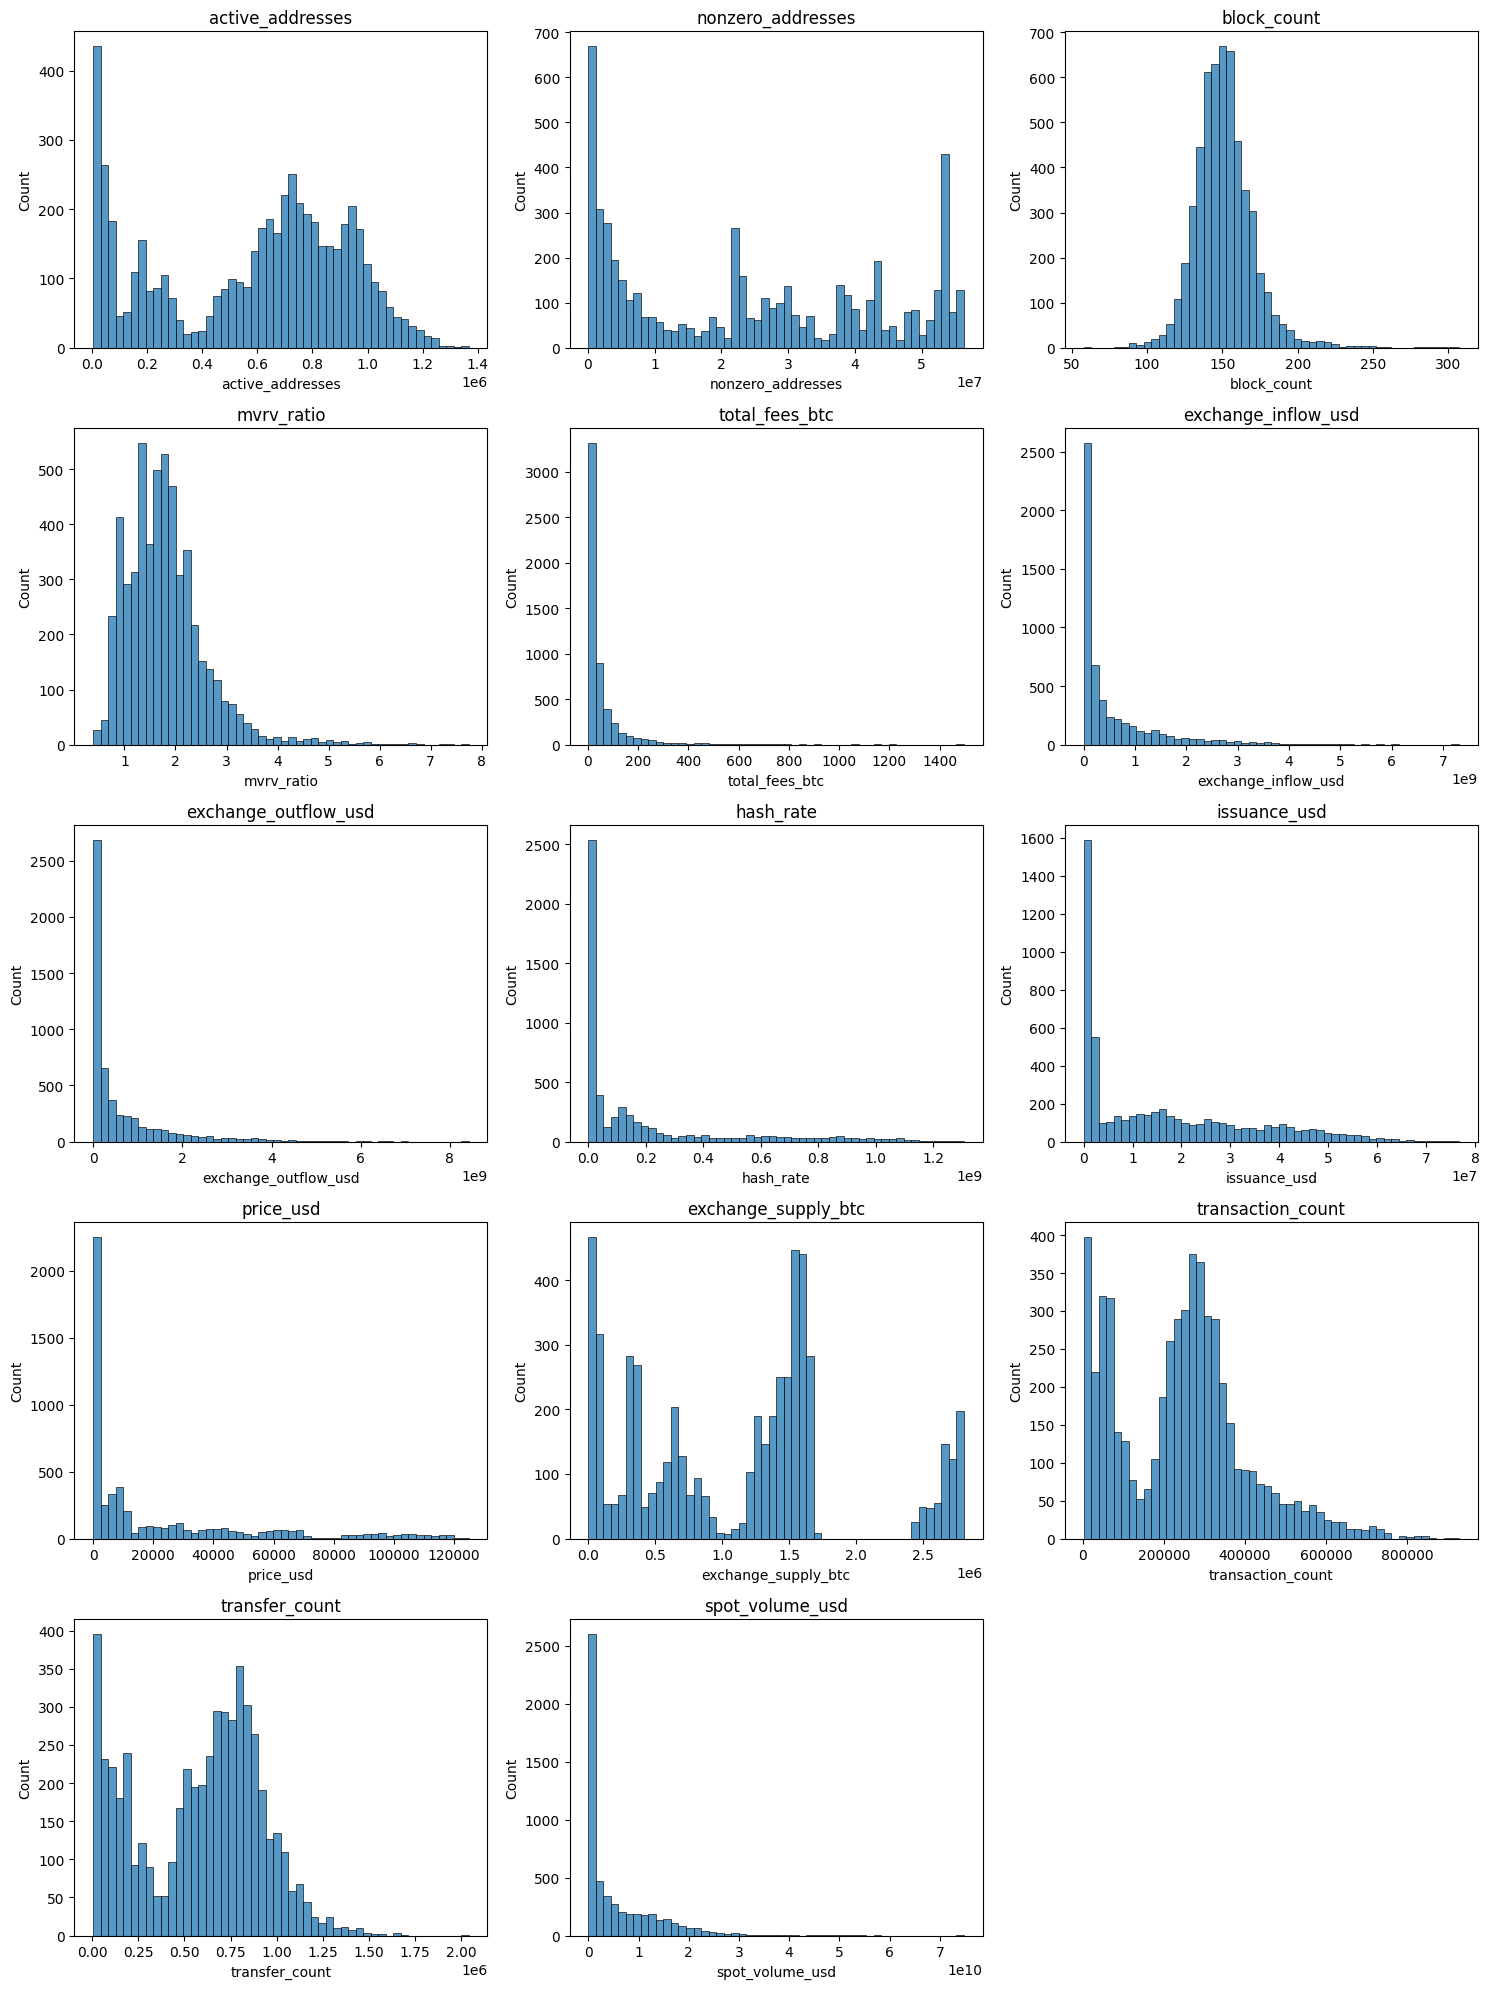

In [159]:
import math

cols = [c for c in df.columns if c != "date"]

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, cols):

    sns.histplot(
        df[col],
        bins=50,
        ax=ax
    )

    ax.set_title(col)

# Leere Subplots entfernen
for ax in axes[len(cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

The histograms already reveal several important characteristics of the dataset. Several variables show a highly right-skewed distribution with a large concentration of observations near zero and a long tail towards high values:

- price_usd
- hash_rate
- issuance_usd
- exchange_inflow_usd
- exchange_outflow_usd
- total_fees_btc
- spot_volume_usd

This makes absolutely sense with Bitcoin's strong long-term growth trend. Early years contain very small values compared to recent years, causing most observations to be near the lower end of the distribution. Given that the hypothesis holds, this shouldn't be a real problem as I can transform these variables into %-changes over specific time windows to avoid clustering primarily based on the time period.

Several variables show more complex distributions with multiple peaks or broader distributions:

- active_addresses
- nonzero_addresses
- transaction_count
- transfer_count
- exchange_supply_btc

These distributions could contain different market states or be a result of the 4-year Bitcoin cycle; the timeseries analysis might tell us more here. 

And then there are variables that appear approximately stationary, what would be ideal if it would hold for the different time periods too:

- The MVRV ratio shows a relatively stable distribution with moderate skewness and no obvious long-term growth pattern, meaning that no transformation nor engineering would be needed.

- The histogram of block_count is close to a normal distribution centered around the expected Bitcoin block production rate. Since Bitcoin adjusts mining difficulty to maintain approximately one block every ten minutes, the variable may mainly reflect random variation rather than meaningful market information. This will be investigated further using the time-series plots. If the hypothesis holds, then the block_count variable will be dropped as it would only add noise.

The histogram analysis suggests that many variables are heavily influenced by Bitcoin's long-term growth and adoption trend. However, histograms alone ignore the temporal ordering of observations and therefore cannot distinguish between real market regimes and simple time trends.

The next step is to inspect each variable as a time series in order to check whether the observed distributions come from structural market regimes, long-term trends, or just randomness.

### Distribution and Time-Series Inspection

Each remaining variable is now inspected visually using two complementary perspectives:

1. **Histogram:** shows the distribution, skewness, outliers and whether the variable is dominated by a few extreme observations - again here just as for comparison.
2. **Time-series plot:** shows whether the variable contains a strong long-term trend, regime-like cycles, structural breaks or mostly random noise.

This step is important because histograms alone ignore the temporal order of the data. Since the project aims to identify latent Bitcoin market regimes, each variable needs to be assessed not only by its distribution, but also by its behaviour over time. 

For example can the distribution look heavily skewed, but incorporating time it could show an equal distribution of skewness in all periods of time -> This would be good for our algorithms as it would not cluster around 'early = low, later = high' due to a general upward trend but extract the structure inside the different periods of time. On the other hand, a distribution could look approximately 'normal' but actually having low values only in the early Bitcoin Phase and higher values later, what would lead to clustering early vs. late again not bear vs. bull vs. sideways vs. regime change phases.

 Based on this inspection, variables will be labeled as suitable in levels, requiring transformation, or potentially unsuitable for clustering.
 The transformations will happen later in the feature engineering phase, for now. For now, only the recommended transformation will be discussed and noted. Generally, possible transformations include:

 - **Growth rates (%-Changes)**: Dependent on the variable and what makes economically sense, the growth rates of 30, 90 or 180 days will be derived later. I will not just simply difference by taking the daily growth rates as regimes are not a thing of short term fluctuations but of longer level-changes that I can capture with growthrates of higher time windows.

 - **Moving Averages (MAs)**: Since daily values fluctuate much, a growthrate dependend on another fluctuating value will to some part also just depend on randomness. As I want to reduce the noise so that the algorithm can find the real structure in the data, I might first calculate MAs of the respective daily data points and then derive the growthrates by incorporating todays MA value - resperctive past MA value. This approach should mostly only be taken with highly volatile values, not with generally more stable values that can not fluctuate that much, i.e. hash rates.

 - **Rolling Z-Scores**: Rolling z-scores will be used to normalize variables relative to their recent history. This highlights unusual deviations from local trends and makes variables with different scales more comparable over time.

 - **Logarithms**: After thinking it through, logarithmic transformations do not make much sense here; They might make the later derived growth rates symmetric, but at the same time the logarithm would compress the extreme values -> And that is something I definitely do NOT want. The extreme values are, considering market regimes and possible reverse signals, probably the most important information pieces. And by compressing them with the logarithmic transformation, they would have much less strength in the data, and as such might not carry enough informative power anymore to be a reason for f.e. another cluster.

- **Time encoding**: I do not plan to apply cyclical time encoding (sine/cosine transformations). While observations close in time are likely to have similar market conditions, the goal of this project is to identify market regimes based on economic, network, and market variables rather than calendar time. In addition, sine/cosine encoding is mainly useful for recurring seasonal patterns (e.g., days, weeks, months), which, based on topic expertise, do not play a role within Bitcoin - if any then there are cycles related to the halving events etc. Generally, the relevant time information should already be reflected in the selected features, and with that, allowing the algorithms to extract the actual market signals instead of learning the time dimension itself. If the results are not satisfying in the end, then additional iteration with time encoding can still be done.

In [160]:
# ============================================================
# Helper function: histogram + time-series plot for one variable
# ============================================================

def inspect_variable(df, col):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[col].dropna(), bins=50, ax=axes[0])
    axes[0].set_title(f"Histogram: {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    axes[1].plot(df["date"], df[col])
    axes[1].set_title(f"Time series: {col}")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

#### Active Addresses

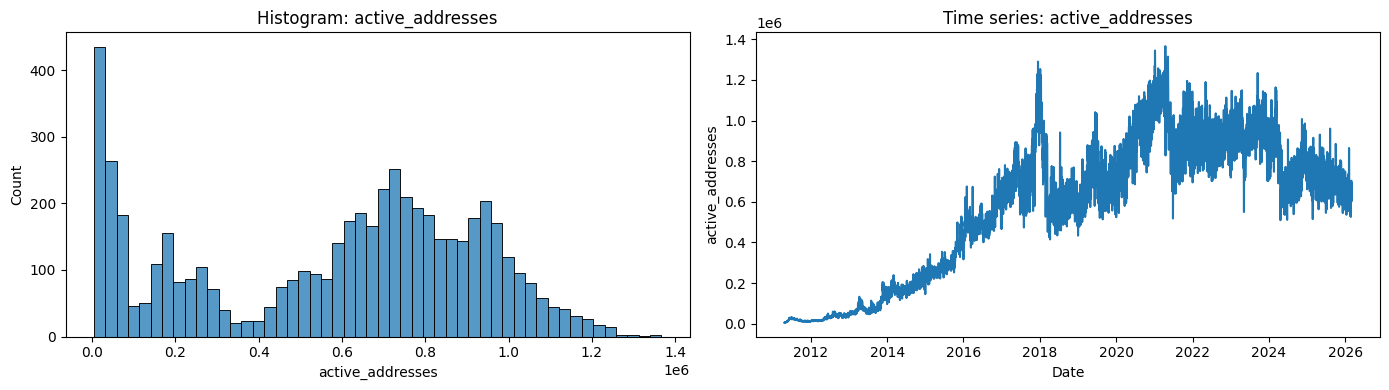

In [161]:
inspect_variable(df, "active_addresses")

**Conclusion**: We clearly see a general upward trend in the early years up until ca. 2016; using this variable in levels would cluster it in early vs late. The intersting part is, that after 2016, the distribution appear mostly stationary, with similar medians throughout different time periods, showing possible different regimes, while in the end, still not convincingly being stationary over the whole process (bull after 2024 has similar levels as bear in 2019), so transformations could still make sense. But still, taking the whole data and then deriving growth rates would still cluster into early vs. late, as the early growth rates (since they had an upwards trend vs later quasi-stationarity) would be generally higher.

Decision:
- First Option: Delete pre-2016 and take Growth Rates or Rolling Z-Scores; no MA needed as fluctuation is not enormous
- Second Option: Delete pre-2016 and keep Level information (experimental)

-> Anyways: Delete pre-2016 necessary!

#### Nonzero Addresses

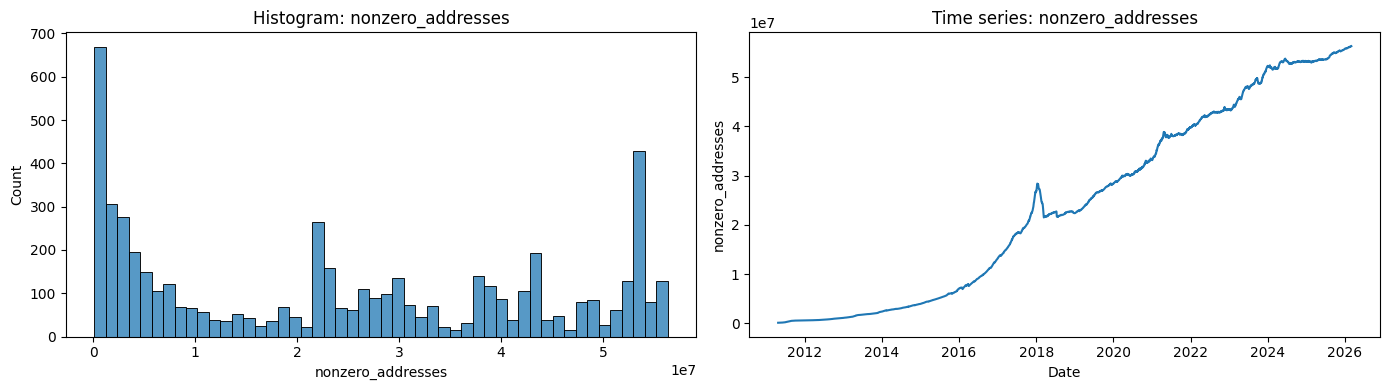

In [162]:
inspect_variable(df, "nonzero_addresses")

**Conclusion**: As expected, it keeps growing continuously - the good thing is, the growth seems to follow a clear linear trend, and as such, can be handled well, except for the time period before 2016 where the growth rate seemed to follow an exponential trend; Growth rates starting from 2016 on could look very stationary in their distribution and allow pretty well for regime detection.

Decision:

- Delete pre-2016 and Growth rates transformation, no MA needed since no high fluctuations, or Rolling Z-Scores.

#### Block Count

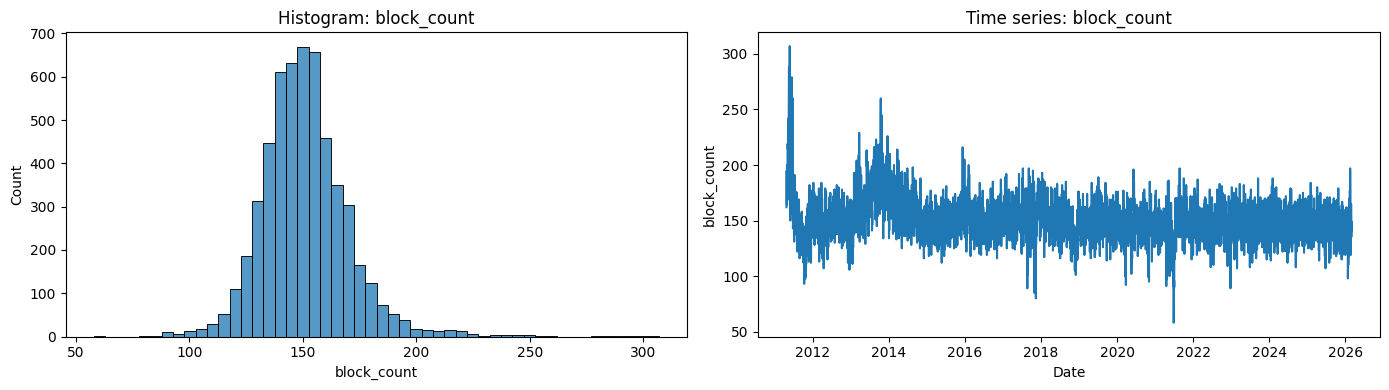

In [163]:
inspect_variable(df, "block_count")

**Conclusion**: Unsuitable data pre 2016, afterwards strongly stationary without a trend. Not even growth rates would be necessary. As indicated before, this was expected due to Bitcoin adjusting network difficulty as to make block production generally take approx. 10 minutes per block, ALWAYS. What is interesting are the spikes that happen mostly during close-to-peak bullmarket phases. From an economic reasoning point, the fact that the number of blocks per day can drop during these phases would only make sense if people would try to front-run blocks in order to secure more newly mined Bitcoins when hitting a lucky-block very early on. This could lead to less hash power for a single day and more for the next if this scenario would happen in the end of the day, and as such with less blocks produced in a single day. Anything else woud not make sense here. Looking at it and giving the generally very low chances of frontrunning in mining, especially at a specific time during the day, it makes more sense to exclude this variable as chances are VERY HIGH that it only contains noise.

Decision:

- Exclude Block Count due to high possibility of only noise in structure.

#### Transaction Count

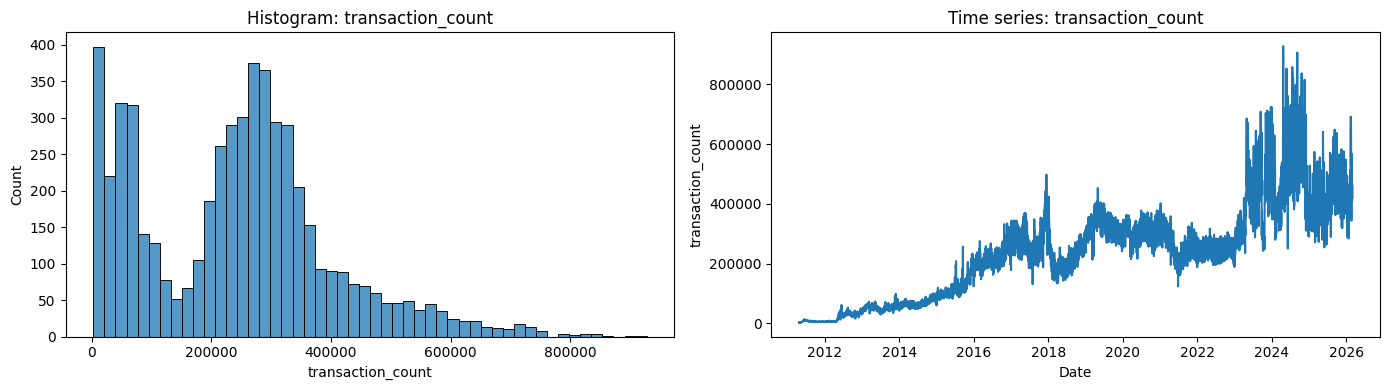

In [164]:
inspect_variable(df, "transaction_count")

**Conclusion**: The time series looks well distributed without a strong exponential component and strong fluctuations inside of time periods, showing most probably regimes. At the same times, the levels change from 2016 to 2024 for example. A simple Growth Rate would make much sense here and would account for the change in levels. 

Decision:
- Take Growth Rate + Possibly MA to account for high fluctuations, or Rolling Z-Scores. All data should be useful here as the function of growth seems generally to hover around levels and change the level from time to time (except for an upward trend from 2014-2016), but probably cutting away early data might still help as growthrates could have been generally higher early on.

#### Transfer Count

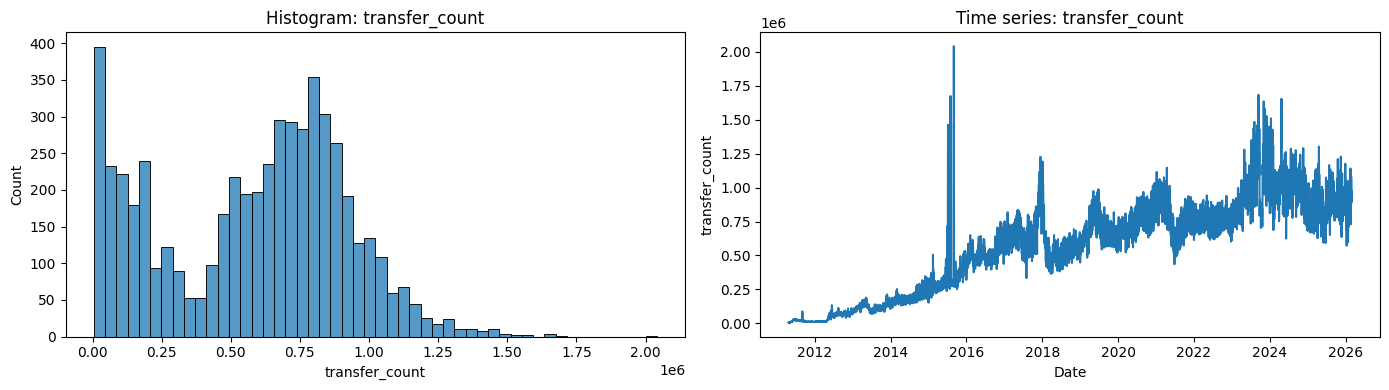

In [165]:
inspect_variable(df, "transfer_count")

**Conclusion**: The time series shows similar patterns to the histogram; After 2016, the variable shows mostly stationarity and a slight upwards trend with different possible regime changes. Before, it was following a clear upwards trend, and therefore, should be excluded

Decision: 
- Delete pre-2016 and take Growth Rates or Rolling Z-Scores. 

#### Hash Rate

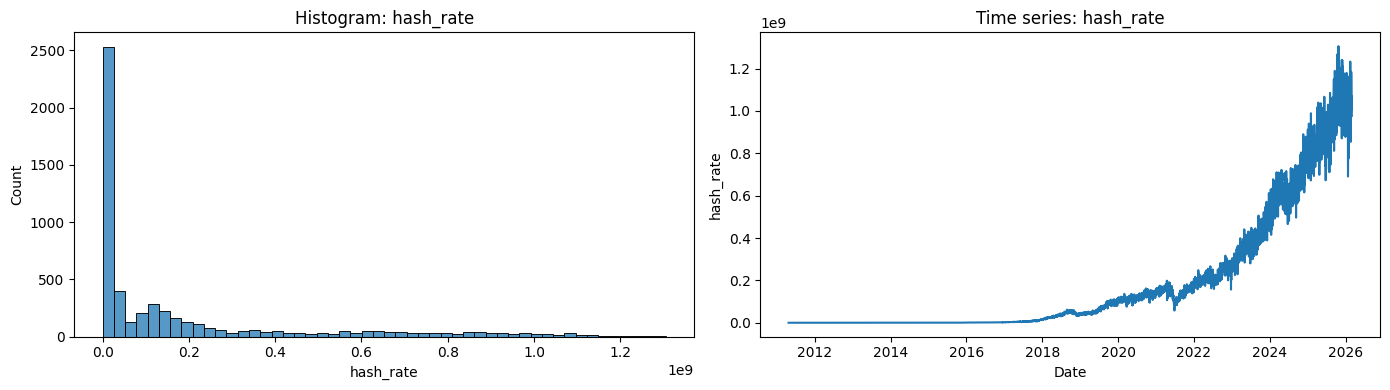

In [166]:
inspect_variable(df, "hash_rate")

**Conclusion**: The hashrate shows a clear pattern of an exponential growth function. It is unclear how the early growth function would have looked like based on the visualization as is typical with exponential growth rates.

Decision:
- Take the growth rates, or Rolling Z-Scores. Possibly taking out earlier data can be helpful.

#### Total Fees in BTC

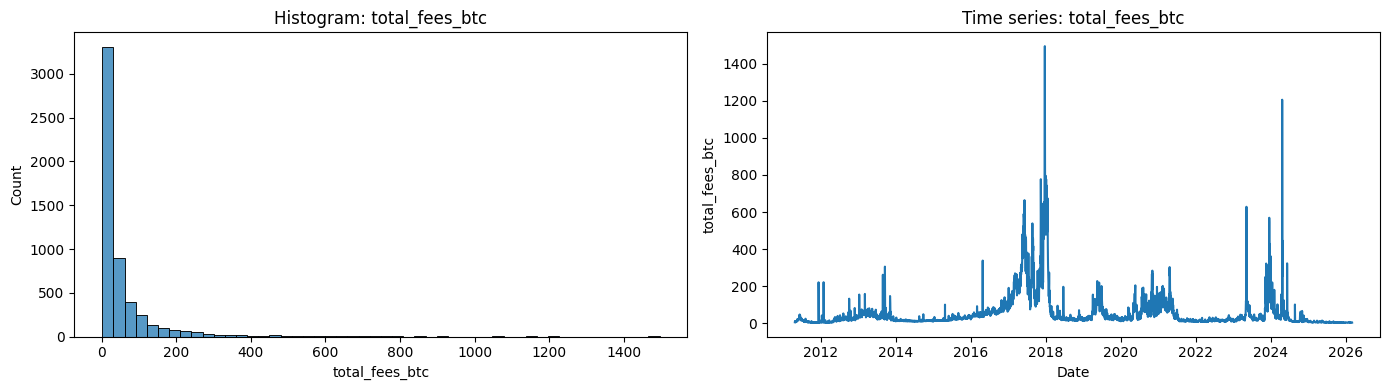

In [167]:
inspect_variable(df, "total_fees_btc")

**Conclusion**: Unexpectedly, the fees, valued in the BTC value in the respective time period, look very good. The low values are very evenly distributed, similar to the high values, coinciding mostly with bull market phases. Given this, it looks as if neither the USD-conversion nor a transformation is necessary.

Decision:
- Keep it in Level, whole period possible

#### Issuance of BTC in USD

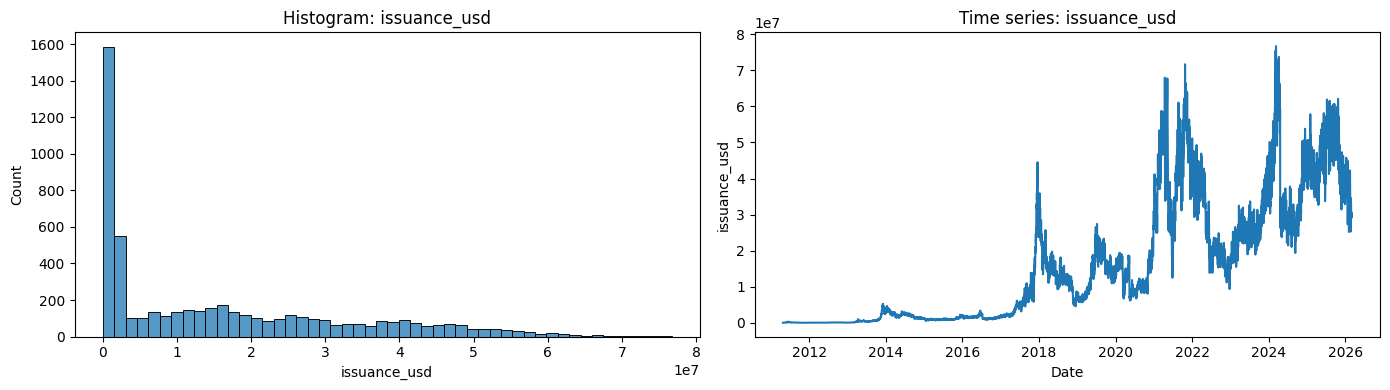

In [168]:
inspect_variable(df, "issuance_usd")

**Conclusion**: There seems to be a general trend upwards, with high fluctuations between bear and bull market phases - this makes sense as it is the result of a combination of a deterministic function that changes the level all 4 years X the price of Bitcoin. Still, by incorporating the level change, it could add information. Generally, a transformation is necessary, and possibly an exclusion of early data could be helpful due to unclear structure.

Decision:
- Take Growth or Rolling Z-Scores, possibly excluding early data.
-> Care, might be redundant information, check with correlation to price.

#### Exchange Supply in BTC

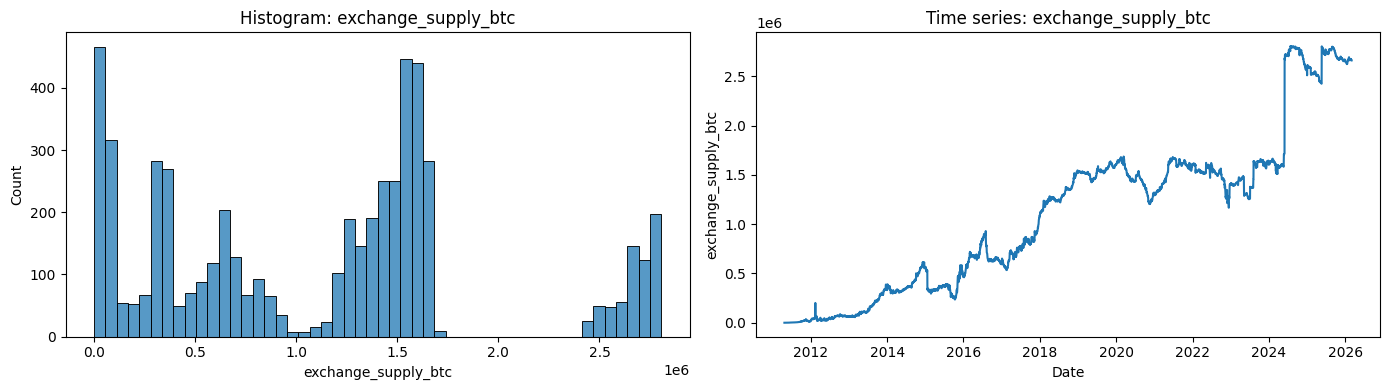

In [169]:
inspect_variable(df, "exchange_supply_btc")

**Conclusion**: A very interesting perspective; a general upwards trend with level shifts in it, ideal for a transformation. The early years seem not to be as much of a problem as with other variables.

Decision:
- Take Growth or Rolling Z-Score. Can keep the whole period.

#### Exchange Inflow in USD

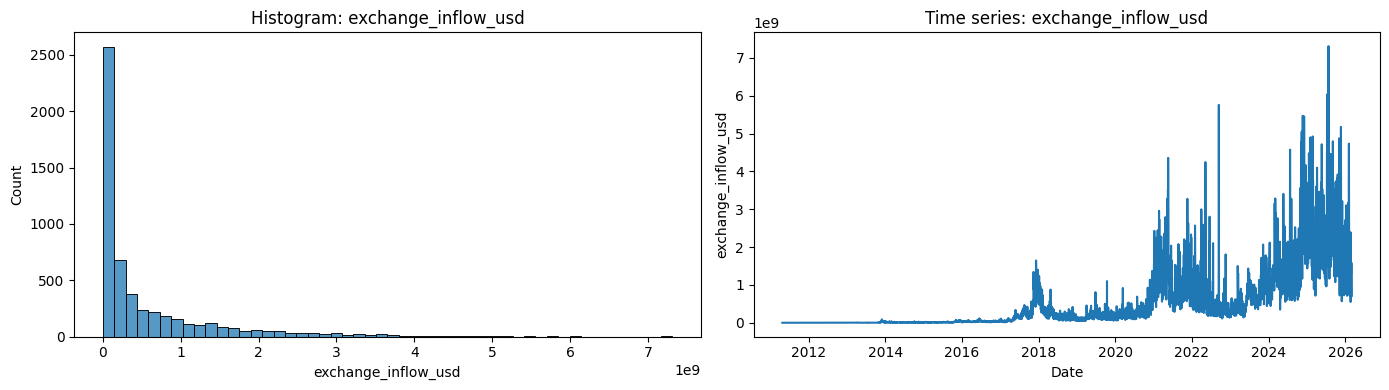

In [170]:
inspect_variable(df, "exchange_inflow_usd")

**Conclusion**: Seems to follow an exponential function, with regimes clearly indicated. Transform and possibly an exclusion of early data could be helpful due to unclear structure.

Decision:
- Growth Rate or Rolling Z-Score.
-> Possibly excluding early years data

#### Exchange Outflow in USD

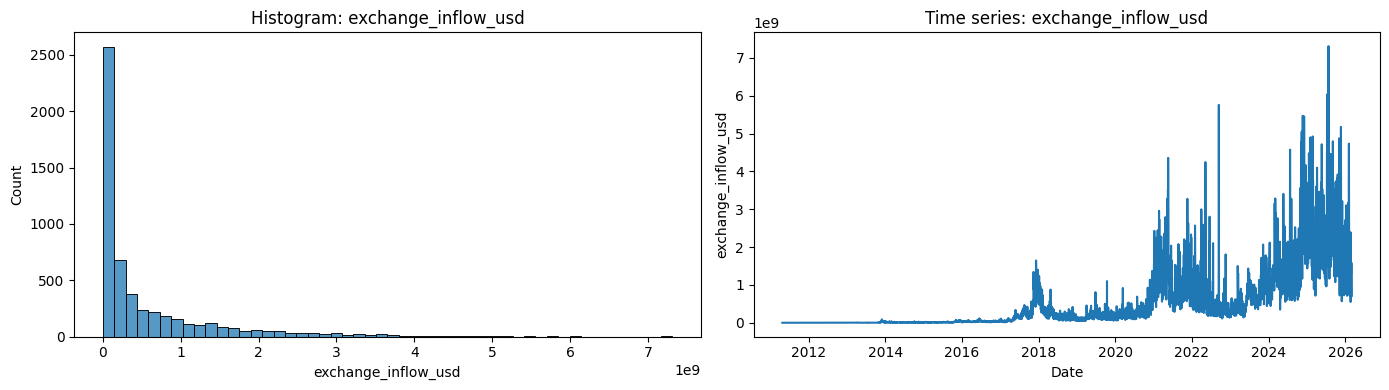

In [171]:
inspect_variable(df, "exchange_inflow_usd")

**Conclusion**: Same picture as with exchange outflows - exponential function and possibly an exclusion of early data could be helpful due to unclear structure.

Decision:
- Take Growth or Rolling Z-Scores. Possibly excluding early years data.

#### Bitcoin Price in USD

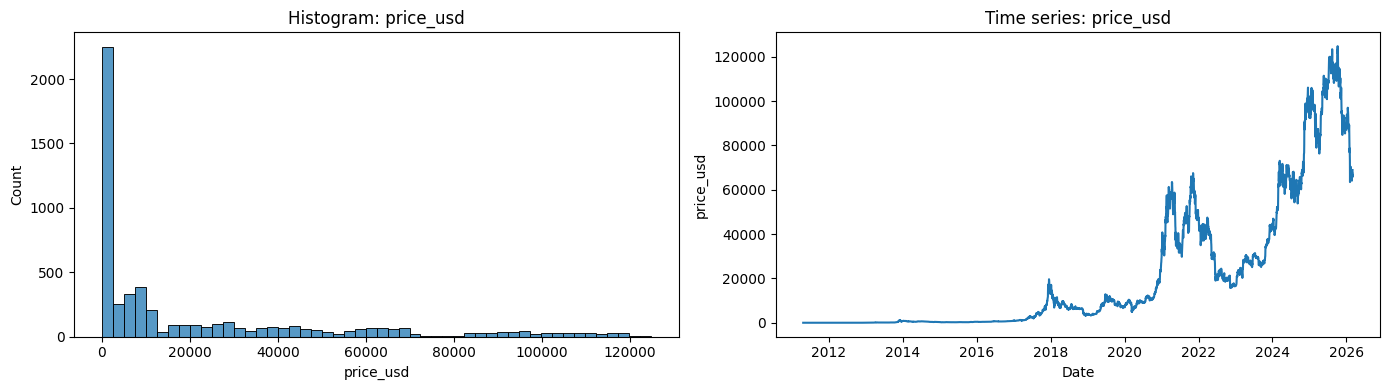

In [172]:
inspect_variable(df, "price_usd")

**Conclusion**: Clear exponential trend with clear bull and bear phases. Growth Rate and possibly an exclusion of early data could be helpful due to unclear structure.

Decision:
- Growth Rate or Rolling Z-Scores. Possibly excluding early data.

#### Market Value to Realized Value (MVRV Score)

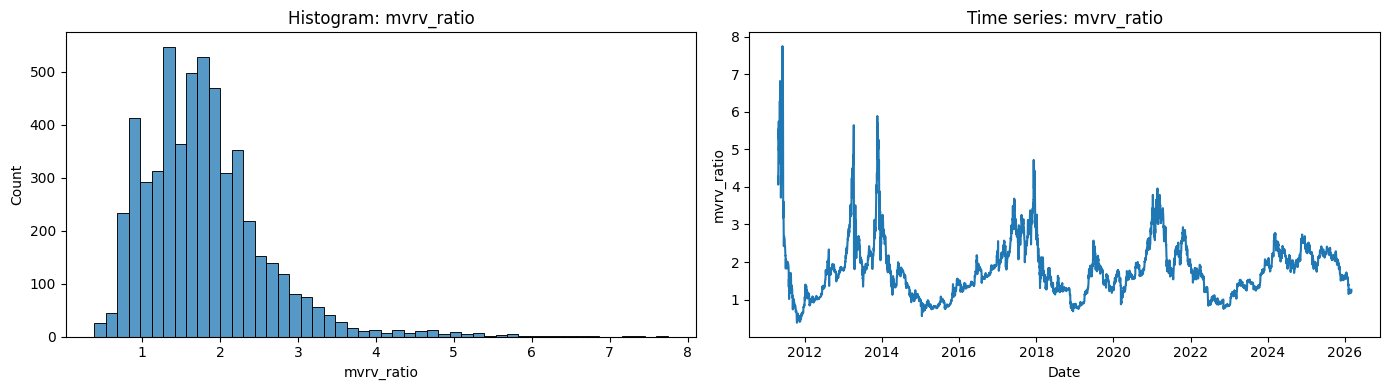

In [173]:
inspect_variable(df, "mvrv_ratio")

**Conclusion**: This looks really good; clear stationarity indicating that no transformation might be necessary. The only problem is that the highs keep getting lower and the lows keep getting higher with more time, but it might still be enough for the algo to detect the different regimes in different periods of time. Alternatively, can use Rolling Z-Scores.

Decision:
- Option 1: Take Level, probably exclude up until 2012.
- Option 2: If the clustering does not work well, take Growth or Rolling Z Scores, exclude up until 2012.

#### Spot Trading Volume in USD

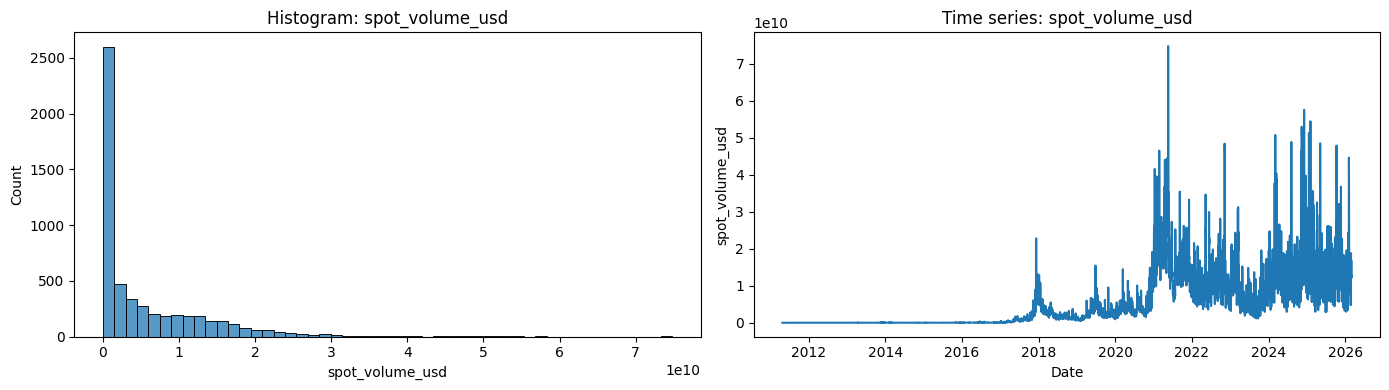

In [174]:
inspect_variable(df, "spot_volume_usd")

**Conclusion**: High stationarity with Level changes in between, ideal for growth rates. Unclear how structure in early days was, so caution.

Decision:
- Take Growth Rate or Rolling Z-Score, possibly excluding early data.

#### Conclusion Decisions

The following table summarizes the results of the initial data exploration and the recommended decisions for transformation etc.

| Variable | Keep? | Transformation (tentative) | Time Restriction | Notes |
|-----------|--------|---------------------------|------------------|--------|
| active_addresses | KEEP | Growth OR rolling Z-Score | Exclude pre-2016 | 2nd Option Exclude pre-2016 and take Levels, might work |
| nonzero_addresses | KEEP | Growth OR rolling Z-Score | Exclude pre-2016 | - |
| block_count | DELETE | - | - | Mostly protocol randomness/noise, no clear economic meaning |
| transaction_count | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |
| transfer_count | KEEP | Growth (possibly MA) OR rolling Z-Score | Exclude pre-2016 | - |
| hash_rate | KEEP | Growth OR rolling Z-Score | Unclear, possibly exclude pre-2016 | -|
| total_fees_btc | KEEP | None, keep Level | None | - |
| issuance_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | Care, possibly redundant since Prod-function x Price with possible level-shift signals |
| exchange_supply_btc | KEEP | Growth (possibly MA) OR rolling Z-Score | None | - |
| exchange_inflow_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |
| exchange_outflow_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |
| price_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |
| mvrv_ratio | KEEP | None, keep Level | None or pre-2012 | 2nd Option if not working well, take Growth |
| spot_volume_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |

**In Short**:
- block_count will be deleted
- transformation necessary everywhere (growth, rolling Z-score) except for mvrv_ratio and total_fees_btc
- exclude data prior to 2016 after calculating the transformations makes very much sense and will be done; if things do not work well with clustering, one can still go back and do a robustness check for the whole timeperiod.

In [175]:
# ============================================================
# Remove block_count
# ============================================================

df = df.drop(columns=["block_count"])

print(df.shape)

(5427, 14)


### Correlation Analysis of RAW Variables (Explorative)

I will just do a quick correlation analysis for exploration reasons - the relevant correlation analysis will be the one after transformations. Based on this one, nothing will be deleted.

#### Correlation Matrix

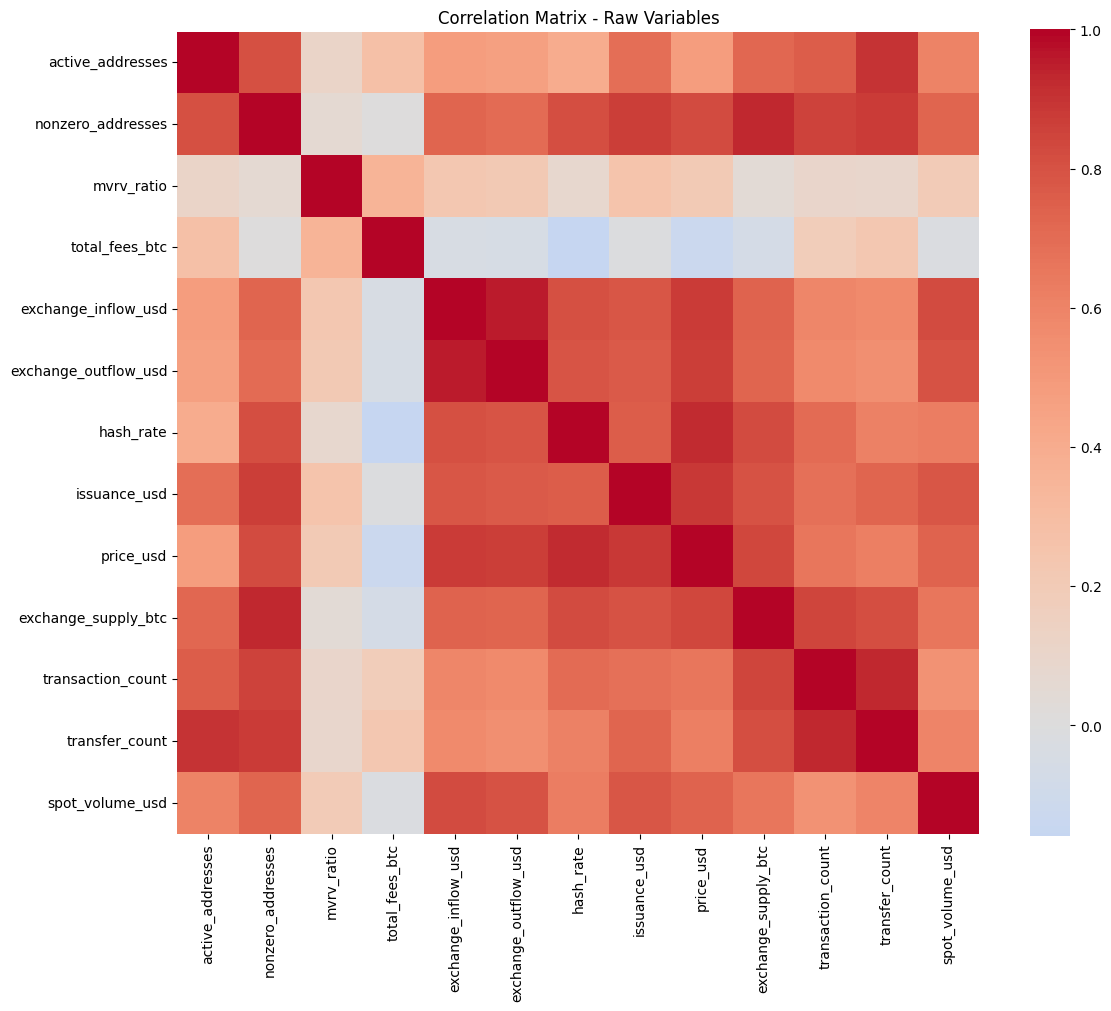

In [176]:
# ============================================================
# Correlation Matrix (raw variables)
# ============================================================

corr_matrix = (
    df
    .drop(columns="date")
    .corr()
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix - Raw Variables")
plt.tight_layout()

plt.show()

A general high correlation, what also makes sense since the growth trend of Bitcoin can be found in nearly variable expect for mvrv_ratio and total_fees_btc, what is again visible hear with their generally low correlations with the rest of the variables - confirming my decision to take levels there.

#### Top Correlations

In [177]:
# ============================================================
# Top correlations
# ============================================================

corr_pairs = (
    corr_matrix
    .abs()
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(20)

exchange_inflow_usd   exchange_outflow_usd    0.954958
transaction_count     transfer_count          0.931703
nonzero_addresses     exchange_supply_btc     0.931375
hash_rate             price_usd               0.927045
active_addresses      transfer_count          0.899212
issuance_usd          price_usd               0.886244
exchange_inflow_usd   price_usd               0.880560
nonzero_addresses     transfer_count          0.878425
exchange_outflow_usd  price_usd               0.867917
nonzero_addresses     issuance_usd            0.865057
                      transaction_count       0.851806
exchange_supply_btc   transaction_count       0.845672
price_usd             exchange_supply_btc     0.836332
exchange_inflow_usd   spot_volume_usd         0.825203
nonzero_addresses     price_usd               0.824096
hash_rate             exchange_supply_btc     0.822341
nonzero_addresses     hash_rate               0.817582
exchange_supply_btc   transfer_count          0.814838
active_add

A more specific perspective on the results above; Many correlations >80%, with some up to 95%. Obviously high but due to obvious reasons - as well as no multicollinearity found right now. Especially intersting is the issuance_usd correlation with price_usd at about 88% 'only', indicating that the level shifts might indeed be visible by quite a bit.

I will commence with 02_preprocessing_features from here on.

In [178]:
# ============================================================
# Save cleaned dataset after exploration
# ============================================================

df.to_csv(
    "../data/processed/bitcoin_cleaned_after_exploration.csv",
    index=False
)

print("Saved cleaned dataset.")
print(df.shape)
print(df["date"].min())
print(df["date"].max())

Saved cleaned dataset.
(5427, 14)
2011-04-24 00:00:00
2026-03-02 00:00:00
